In [1]:
import sys
import os
# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))
from simu_PSF_polarMFM_JAX import *
from simu_PSF_polarMFM import *
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch
device = torch.device('cuda')

In [33]:
N_photons=1000 # number of photons collected 
N=80 # discretization of the BFP
l_pixel=16 #pixel size in micrometer
NA=1.4 # numerical aperture
mag=100 # first magnification
lambd=617 # wavelength
f_tube=200 # tube lens focal
MAG=200/150 # second magnification

In [34]:
x, y, th1, phi, (Ex0, Ex1, Ex2), (Ey0, Ey1, Ey2), r, r_cut, k, f_o = vectorial_BFP_perfect_focus_jax(N, NA, mag, lambd, f_tube)

In [35]:
zernike_base = generate_zernike_base_jax(r_cut, N, zernike_order=4, device=device)

In [36]:
u, v, Npadding = padding(r, r_cut, k, f_o)
print(Npadding)

74


In [37]:
xp = jnp.array([0.2,0.,0.,0.,0.])
yp = jnp.array([0.,0.,0.,0.,0.])
zp = jnp.array([1.,1.,1.,1.,1.])
d = -1.
second_plane = jnp.array([-0.35, 0, 0.35,0])
polar_projections = jnp.array([0., 45., 0.,0.])

In [38]:
th1 = pad_jax(th1, Npadding)
phi = pad_jax(phi, Npadding)
Ex0 = pad_jax(Ex0, Npadding)
Ex1 = pad_jax(Ex1, Npadding)
Ex2 = pad_jax(Ex2, Npadding)
Ey0 = pad_jax(Ey0, Npadding)
Ey1 = pad_jax(Ey1, Npadding)
Ey2 = pad_jax(Ey2, Npadding)
zernike_base = pad_jax(zernike_base, Npadding)

In [39]:
zernike_base.shape

(15, 154, 154)

In [40]:
Mj = compute_M_jax(xp, yp, zp, d, x, y, th1, phi, Ex0, Ex1, Ex2, Ey0, Ey1, Ey2, u, v, zernike_base, jnp.zeros((4,15)), jnp.zeros((4,15)),  second_plane=second_plane
                  , polar_projections=polar_projections)

In [41]:
rho = jnp.array([20.,30.,40.,80.,100.])
eta = jnp.array([10.,60.,30.,80.,50.])
delta = jnp.array([100.,100.,100.,100.,100.])
N_photons = jnp.array([1000.,1000.,1000.,1000.,1000.])

In [42]:
psf_jax = PSF_jax(rho, eta, delta, Mj, N_photons)

# not jax

In [47]:
N_photons=torch.tensor(1000, device=device) # number of photons collected 
N=torch.tensor(80, device=device) # discretization of the BFP
l_pixel=torch.tensor(16, device=device) #pixel size in micrometer
NA=torch.tensor(1.4, device=device) # numerical aperture
mag=torch.tensor(100, device=device) # first magnification
lambd=torch.tensor(617, device=device) # wavelength
f_tube=torch.tensor(200, device=device) # tube lens focal
MAG=torch.tensor(200/150, device=device) # second magnification

In [48]:
x, y, th1, phi, (Ex0, Ex1, Ex2), (Ey0, Ey1, Ey2), r, r_cut, k, f_o = vectorial_BFP_perfect_focus(N, NA, mag, lambd, f_tube, device=device)

In [49]:
zernike_base = generate_zernike_base(r_cut, N, zernike_order=4, device=device)

In [50]:
zernike_base.shape

torch.Size([15, 80, 80])

In [51]:
xp = torch.tensor([0.2,0.,0.,0.,0.], device=device)
yp = torch.tensor([0.,0.,0.,0.,0.], device=device)
zp = torch.tensor([1.,1.,1.,1.,1.], device=device)
d = torch.tensor(-1., device=device)
second_plane = torch.tensor([-0.35, 0, 0.35,0.], device=device)
polar_projections = np.array([0, 45, 0,0.])

In [52]:
phase_maskx = torch.ones((zernike_base.shape[-1], zernike_base.shape[-1]), device=device)
phase_masky = phase_maskx

In [53]:
l_pixel

tensor(16, device='cuda:0')

In [54]:
u, v, M = compute_M(xp, yp, zp, d, x, y, th1, phi, Ex0, Ex1, Ex2, Ey0, Ey1, Ey2, r, r_cut, k, f_o, phase_maskx, 
              phase_masky, zernike_base, zernike_coefs_x=torch.zeros(4,15, device=device), zernike_coefs_y=torch.zeros(4,15, device=device), 
              second_plane=second_plane, polar_projections=polar_projections, N=N, l_pixel=l_pixel, NA=NA, mag=mag, lambd=lambd, 
              f_tube=f_tube, MAG=MAG, device='cuda', BFP_version=False, 
              SAF=False, costh2=None)

In [55]:
rho = torch.tensor([20.,30.,40.,80.,100.], device=device)
eta = torch.tensor([10.,60.,30.,80.,50.], device=device)
delta = torch.tensor([100.,100.,100.,100.,100.], device=device)
N_photons = torch.tensor([1000.,1000.,1000.,1000.,1000.], device=device)

In [56]:
psf = PSF(rho, eta, delta, M, N_photons)

(70.0, 85.0)

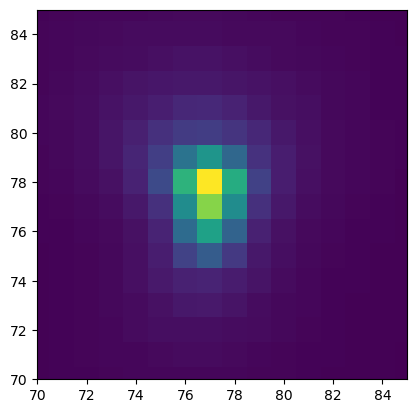

In [71]:
plt.imshow(psf[2,3,1].detach().cpu().numpy())
plt.xlim((70,85))
plt.ylim((70,85))

(70.0, 85.0)

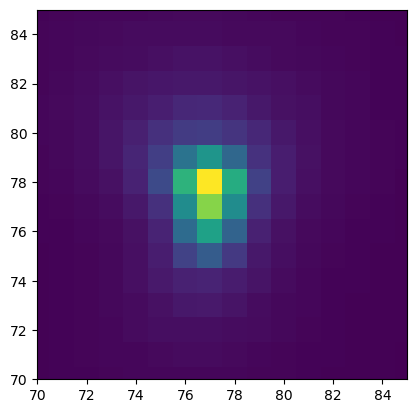

In [72]:
plt.imshow(psf_jax[2,3,1])
plt.xlim((70,85))
plt.ylim((70,85))

In [59]:
psf_jax.shape

(5, 4, 2, 154, 154)

In [60]:
psf.shape

torch.Size([5, 4, 2, 154, 154])

In [61]:
M.shape

torch.Size([5, 4, 2, 3, 3, 154, 154])

In [62]:
Mj.shape

(5, 4, 2, 3, 3, 154, 154)

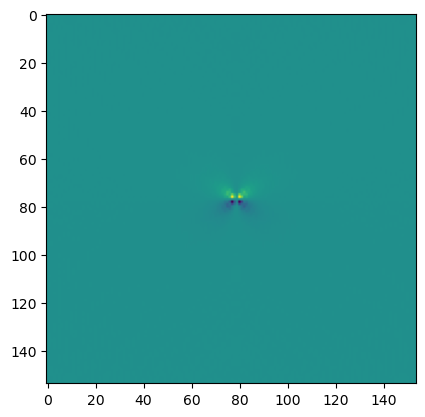

In [63]:
plt.imshow(torch.real(M[0,0,0,1,2].detach().cpu()))

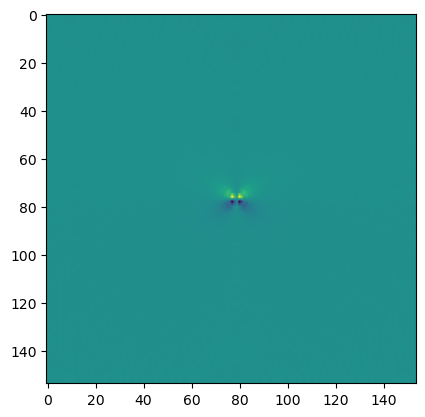

In [64]:
plt.imshow(jnp.real(Mj[0,0,0,1,2]))